# **Predict Medical Insurance Costs**

We will build a model to `Predict Medical Insurance Costs` based on a patient's age, BMI, smoking habits, and other factors.

### **1. Import Libraries and Load Data**
First, we load the data and look at its structure.

In [1]:
import pandas as pd 
import numpy as np

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [5]:
df.shape

(1338, 7)

In [6]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [7]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.describe(include = 'string')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

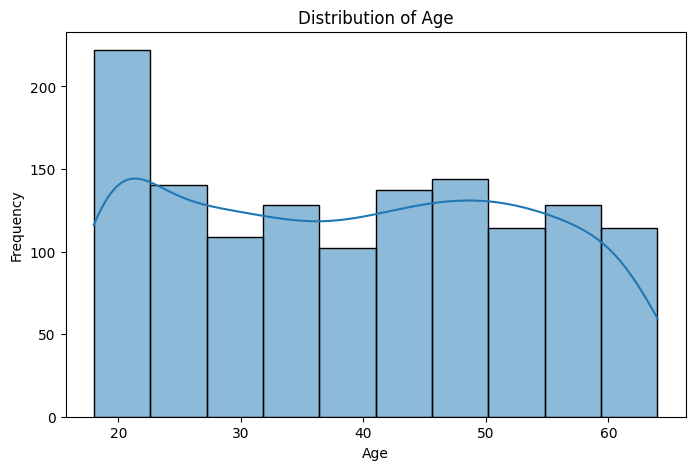

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=10, kde = True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

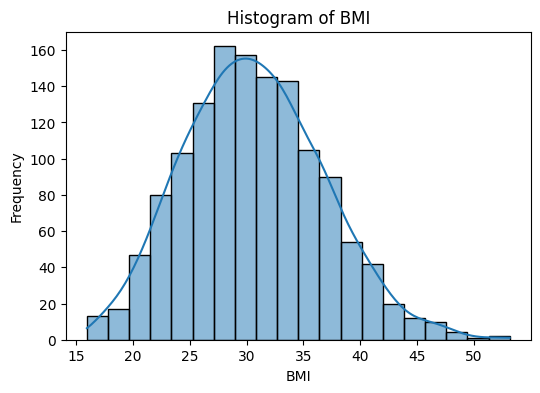

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df["bmi"], bins=20, kde = True)
plt.title("Histogram of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

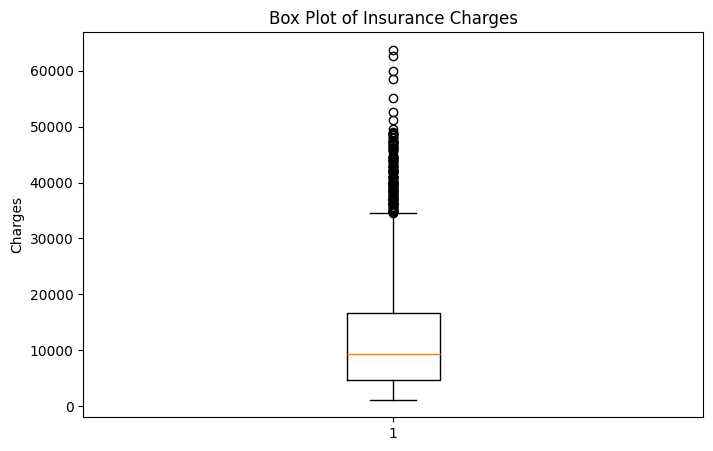

In [13]:
plt.figure(figsize=(8,5))
plt.boxplot(df["charges"])
plt.title("Box Plot of Insurance Charges")
plt.ylabel("Charges")
plt.show()

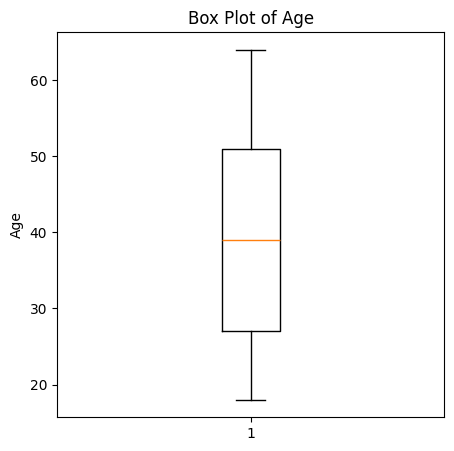

In [14]:
plt.figure(figsize=(5,5))
plt.boxplot(df["age"])
plt.title("Box Plot of Age")
plt.ylabel("Age")
plt.show()

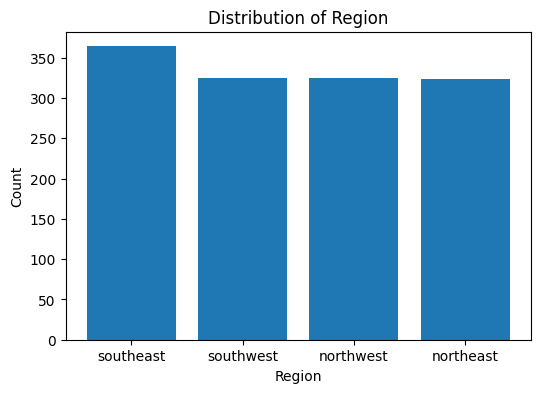

In [15]:
region_counts = df["region"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(region_counts.index, region_counts.values)
plt.title("Distribution of Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

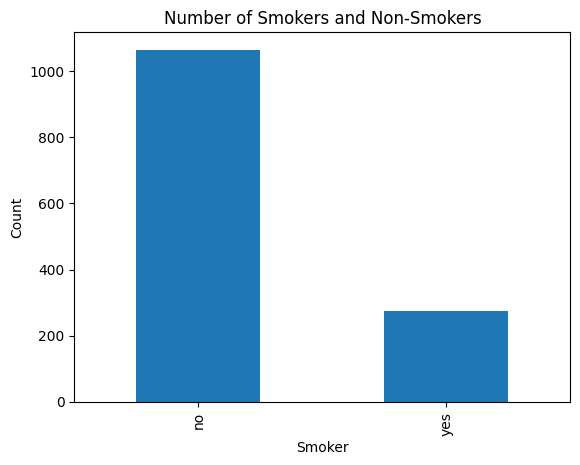

In [16]:
df["smoker"].value_counts().plot(kind="bar")
plt.title("Number of Smokers and Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Count")
plt.show() 

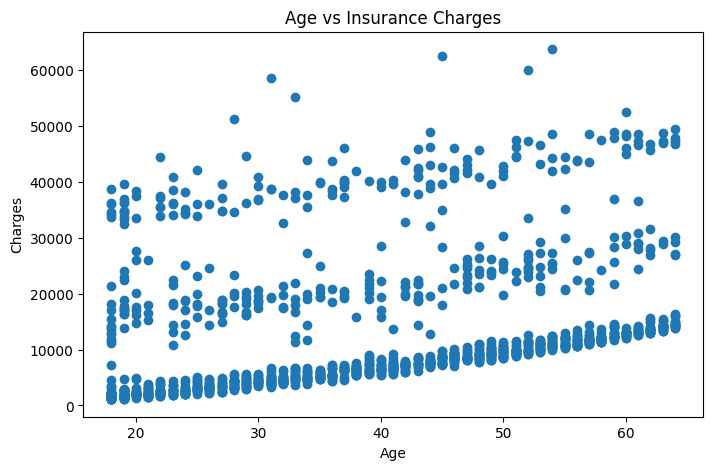

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df["age"], df["charges"])
plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show() 

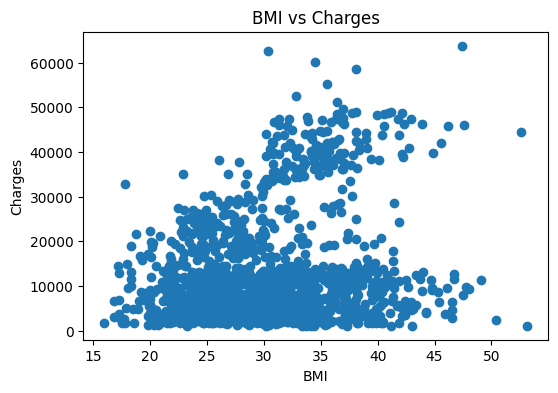

In [18]:
plt.figure(figsize=(6,4))
plt.scatter(df["bmi"], df["charges"])
plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

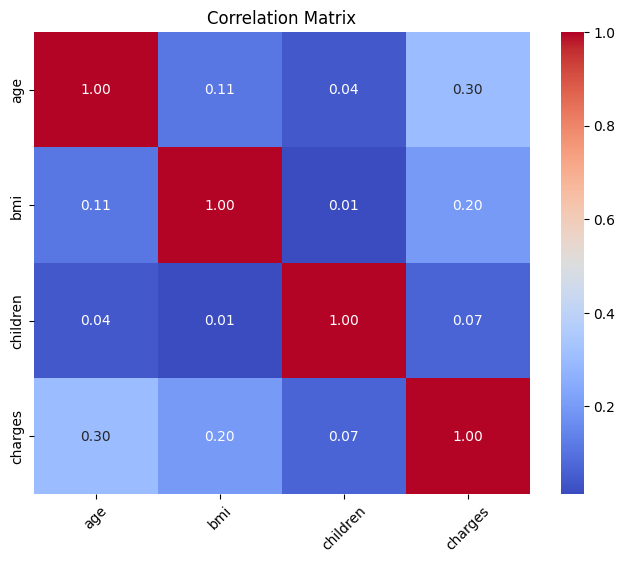

In [19]:
# Select only numerical columns
corr = df.corr(numeric_only=True)
# Plot correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.xticks(rotation=45)
plt.title("Correlation Matrix")
plt.show()

In [20]:
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


In [21]:
# numerical feature has the strongest correlation with charges
corr = df.corr(numeric_only=True)
print(corr["charges"].sort_values(ascending=False))

charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [23]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(1)

In [25]:
df['smoker'].unique()

<StringArray>
['yes', 'no']
Length: 2, dtype: str

In [26]:
df['region'].unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [27]:
df["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [28]:
df[['age', 'bmi', 'charges']].describe()

,age,bmi,charges
count,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,13270.422265
std,14.049960,6.098187,12110.011237
min,18.000000,15.960000,1121.873900
25%,27.000000,26.296250,4740.287150
50%,39.000000,30.400000,9382.033000
75%,51.000000,34.693750,16639.912515
max,64.000000,53.130000,63770.428010


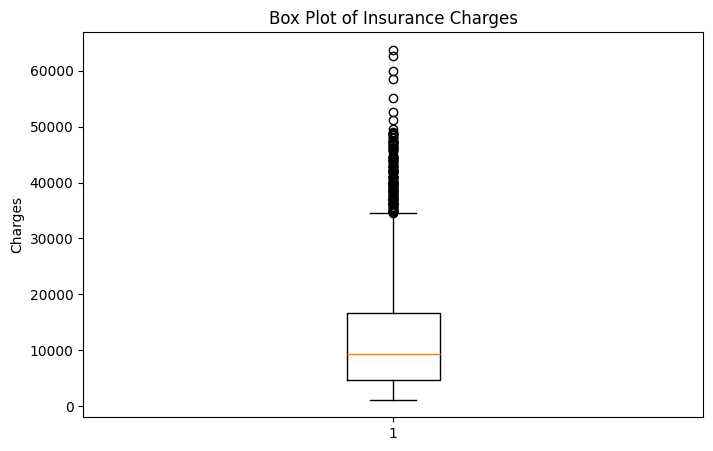

In [29]:
plt.figure(figsize=(8,5))
plt.boxplot(df["charges"])
plt.title("Box Plot of Insurance Charges")
plt.ylabel("Charges")
plt.show() 

In [30]:
Q1 = df["charges"].quantile(0.25)
Q3 = df["charges"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df["charges"] < lower) | (df["charges"] > upper)]
print(outliers.sort_values('charges', ascending = True))

      age     sex     bmi  children smoker     region      charges
623    18    male  33.535         0    yes  northeast  34617.84065
1078   28    male  31.680         0    yes  southeast  34672.14720
223    19    male  34.800         0    yes  southwest  34779.61500
689    27    male  31.130         1    yes  southeast  34806.46770
1291   19    male  34.900         0    yes  southwest  34828.65400
...   ...     ...     ...       ...    ...        ...          ...
819    33  female  35.530         0    yes  northwest  55135.40209
577    31  female  38.095         1    yes  northeast  58571.07448
1230   52    male  34.485         3    yes  northwest  60021.39897
1300   45    male  30.360         0    yes  southeast  62592.87309
543    54  female  47.410         0    yes  southeast  63770.42801

[139 rows x 7 columns]


In [31]:
from scipy.stats import zscore 
df['zscore'] = zscore(df['charges']) 
outliers = df[df['zscore'].abs() > 3]
outliers.sort_values('charges', ascending = True)

,age,sex,bmi,children,smoker,region,charges,zscore
34,28,male,36.400,1,yes,southwest,51194.55914,3.132806
1146,60,male,32.800,0,yes,southwest,52590.82939,3.248148
819,33,female,35.530,0,yes,northwest,55135.40209,3.458348
577,31,female,38.095,1,yes,northeast,58571.07448,3.742159
1230,52,male,34.485,3,yes,northwest,60021.39897,3.861966
1300,45,male,30.360,0,yes,southeast,62592.87309,4.074389
543,54,female,47.410,0,yes,southeast,63770.42801,4.171663


In [32]:
df = df.drop('zscore', axis = 1)

In [33]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["smoker"] = encoder.fit_transform(df["smoker"])

In [34]:
encoded_df = pd.get_dummies(df, columns = ['region'], drop_first = True) 

In [35]:
df = encoded_df

In [36]:
encoder = LabelEncoder()
df["sex"] = encoder.fit_transform(df["sex"])

In [37]:
df.sample(10)

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
1066,48,1,37.290,2,0,8978.18510,False,True,False
1162,30,1,38.830,1,0,18963.17192,False,True,False
120,44,1,37.100,2,0,7740.33700,False,False,True
1301,62,1,30.875,3,1,46718.16325,True,False,False
862,55,0,33.535,2,0,12269.68865,True,False,False
1021,22,0,31.020,3,1,35595.58980,False,True,False
1039,19,1,27.265,2,0,22493.65964,True,False,False
764,45,0,25.175,2,0,9095.06825,False,False,False
1232,54,0,24.605,3,0,12479.70895,True,False,False
629,44,0,38.950,0,1,42983.45850,True,False,False


In [38]:
from sklearn.preprocessing import MinMaxScaler 
scaler = MinMaxScaler() 
scaled_data = scaler.fit_transform(df[['age', 'bmi', 'children']])
normalized_df = pd.DataFrame(scaled_data, columns = ['age', 'bmi', 'children'])

In [39]:
normalized_df.head()

,age,bmi,children
0,0.021739,0.321227,0.0
1,0.000000,0.479150,0.2
2,0.217391,0.458434,0.6
3,0.326087,0.181464,0.0
4,0.304348,0.347592,0.0


In [40]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler() 
scaled_data = scaler.fit_transform(df[['age', 'bmi', 'children']])
standardized_df = pd.DataFrame(scaled_data, columns = ['age', 'bmi', 'children'])

In [41]:
standardized_df.head()

,age,bmi,children
0,-1.438764,-0.453320,-0.908614
1,-1.509965,0.509621,-0.078767
2,-0.797954,0.383307,1.580926
3,-0.441948,-1.305531,-0.908614
4,-0.513149,-0.292556,-0.908614


In [42]:
print("Min-Max Scaling")
print(normalized_df.head())

print("\nStandardization")
print(standardized_df.head())

Min-Max Scaling
        age       bmi  children
0  0.021739  0.321227       0.0
1  0.000000  0.479150       0.2
2  0.217391  0.458434       0.6
3  0.326087  0.181464       0.0
4  0.304348  0.347592       0.0

Standardization
        age       bmi  children
0 -1.438764 -0.453320 -0.908614
1 -1.509965  0.509621 -0.078767
2 -0.797954  0.383307  1.580926
3 -0.441948 -1.305531 -0.908614
4 -0.513149 -0.292556 -0.908614


In [43]:
from sklearn.model_selection import train_test_split 

X = df[["age", "bmi", "children"]]
y = df['charges'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [44]:
from sklearn.preprocessing import MinMaxScaler 
scaler = MinMaxScaler() 
X_train_minmax = scaler.fit_transform(X_train)
X_test_minmax = scaler.transform(X_test) 

In [45]:
print(X_train_minmax[:5])

[[0.60869565 0.10734463 0.4       ]
 [0.63043478 0.22491256 0.        ]
 [0.73913043 0.23944041 0.        ]
 [0.45652174 0.49394673 1.        ]
 [0.7826087  0.14823783 0.6       ]]


In [46]:
print(X_test_minmax[:5])

[[0.58695652 0.24791499 0.4       ]
 [0.39130435 0.37826204 0.        ]
 [1.         0.29391983 0.        ]
 [0.60869565 0.26324993 0.6       ]
 [0.02173913 0.42937853 0.        ]]


In [47]:
print("Training Min:", scaler.data_min_)
print("Training Max:", scaler.data_max_)

# Notice we use transform(), not fit_transform()
X_test_minmax = scaler.transform(X_test)

Training Min: [18.   15.96  0.  ]
Training Max: [64.   53.13  5.  ]


In [48]:
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()

X_train_std = standard.fit_transform(X_train)
X_test_std = standard.transform(X_test)

In [49]:
print("Min-Max Scaled")
print(pd.DataFrame(X_train_minmax, columns=X.columns).describe())

print("\nStandardized")
print(pd.DataFrame(X_train_std, columns=X.columns).describe())

Min-Max Scaled
               age          bmi     children
count  1070.000000  1070.000000  1070.000000
mean      0.464283     0.392801     0.221495
std       0.305956     0.162588     0.243197
min       0.000000     0.000000     0.000000
25%       0.195652     0.275626     0.000000
50%       0.467391     0.383374     0.200000
75%       0.717391     0.498688     0.400000
max       1.000000     1.000000     1.000000

Standardized
                age           bmi      children
count  1.070000e+03  1.070000e+03  1.070000e+03
mean  -1.992176e-16 -4.648410e-17 -2.324205e-17
std    1.000468e+00  1.000468e+00  1.000468e+00
min   -1.518194e+00 -2.417060e+00 -9.111921e-01
25%   -8.784157e-01 -7.210253e-01 -9.111921e-01
50%    1.016470e-02 -5.800739e-02 -8.842793e-02
75%    8.276587e-01  6.515707e-01  7.343363e-01
max    1.751782e+00  3.736342e+00  3.202629e+00


In [50]:
from sklearn.model_selection import train_test_split 

# Separate features and target 
X = df.drop('charges', axis = 1) 
y = df['charges'] 

# Split the dataset 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [51]:
print("X - Train Shape: ", X_train.shape) 
print("X - Test Shape: ", X_test.shape)
print("y - Train Shape: ", y_train.shape)
print("y - Test Shape: ", y_test.shape)

X - Train Shape:  (1070, 8)
X - Test Shape:  (268, 8)
y - Train Shape:  (1070,)
y - Test Shape:  (268,)


In [52]:
X_train.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
560,46,0,19.95,2,0,True,False,False
1285,47,0,24.32,0,0,False,False,False
1142,52,0,24.86,0,0,False,True,False
969,39,0,34.32,5,0,False,True,False
486,54,0,21.47,3,0,True,False,False


In [53]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.20, random_state=10)

In [54]:
from sklearn.linear_model import LinearRegression 
model = LinearRegression() 
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [55]:
model.intercept_

np.float64(-11931.21905032667)

In [56]:
model.coef_

array([ 2.56975706e+02, -1.85916916e+01,  3.37092552e+02,  4.25278784e+02,
        2.36511289e+04, -3.70677326e+02, -6.57864297e+02, -8.09799354e+02])

In [57]:
y_pred = model.predict(X_test)

In [58]:
for feature, coef in zip(X_train.columns, model.coef_):
    print(f"{feature}: {coef}")

age: 256.9757058311942
sex: -18.591691641035993
bmi: 337.0925519487791
children: 425.2787835242934
smoker: 23651.128855761253
region_northwest: -370.6773262277898
region_southeast: -657.8642965646405
region_southwest: -809.7993541824902


In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

In [60]:
mae = mean_absolute_error(y_test, y_pred) 
mse = mean_squared_error(y_test, y_pred) 
rmse = np.sqrt(mse) 
r2 = r2_score(y_test, y_pred)

In [61]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 4181.194473753647
MSE : 33596915.851361446
RMSE: 5796.284659276272
R²  : 0.7835929767120724


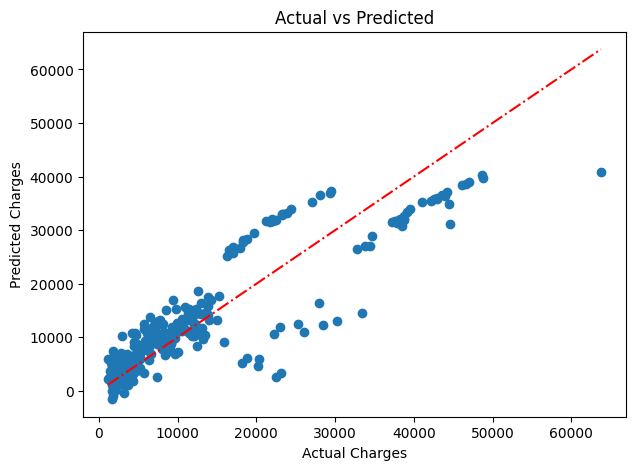

In [91]:
plt.figure(figsize = (7, 5)) 
plt.scatter(y_test, y_pred) 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'red', linestyle = '-.')
plt.xlabel("Actual Charges") 
plt.ylabel("Predicted Charges") 
plt.title("Actual vs Predicted")
plt.show() 

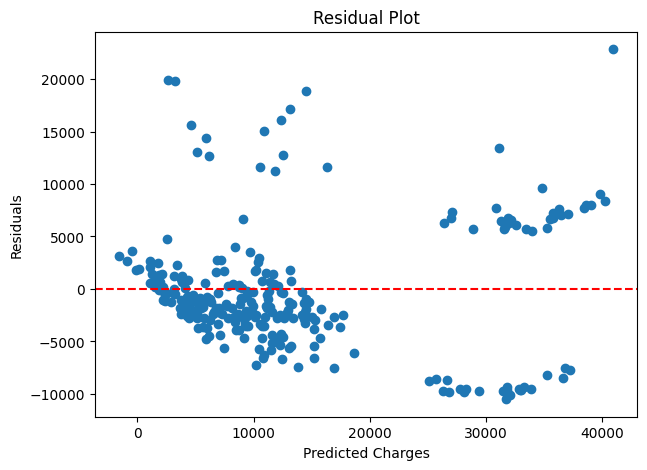

In [89]:
residuals = y_test - y_pred
plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

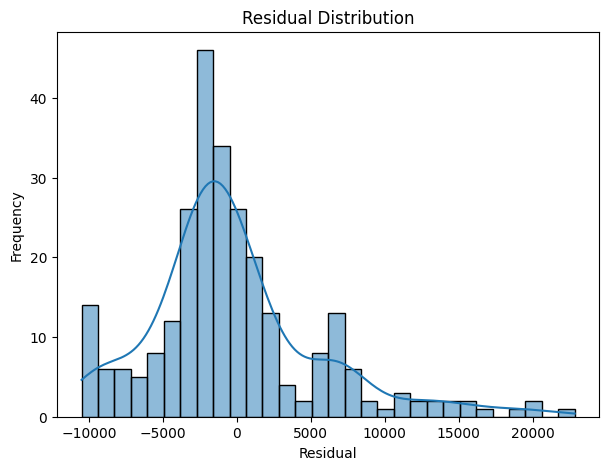

In [67]:
plt.figure(figsize=(7,5))
sns.histplot(residuals, bins=30, kde = True) 
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show() 

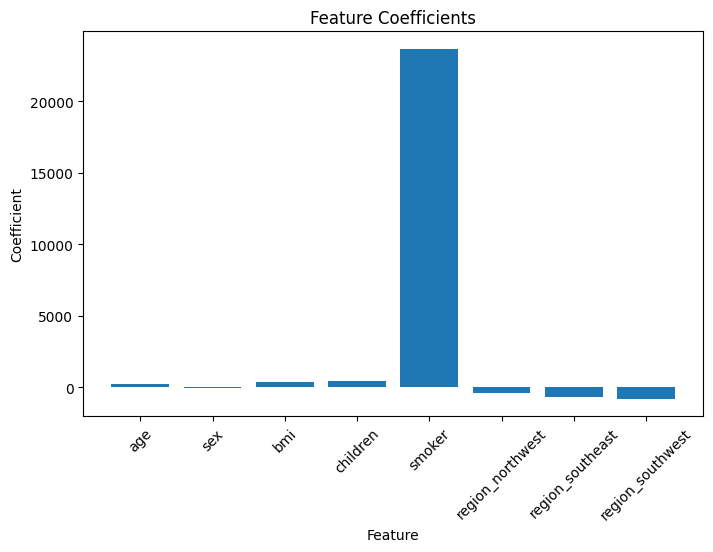

In [93]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

plt.figure(figsize=(8,5))

plt.bar(coef_df["Feature"], coef_df["Coefficient"])

plt.xticks(rotation=45)

plt.xlabel("Feature")
plt.ylabel("Coefficient")
plt.title("Feature Coefficients")

plt.show()

### **2. Data Preprocessing**
Machine Learning models can only understand numbers. Our dataset has text columns (`sex`, `smoker`, `region`) that we must convert into numerical formats. This is called Categorical Encoding.

### **3. Model Training**
Now we create our Linear Regression model and train it using the `fit()` method on our training data.

### **4. Model Evaluation**
To know if our model is any good, we ask it to predict costs for our `X_test data`, which it has never seen before. We then compare its predictions to the actual `y_test` costs using statistical metrics.